# P3 — Regime Labeling

This notebook has two jobs.

1. **Periodic check** that the five regimes are still well-defined: occupancy,
   sojourn, transitions, and per-state profiles for the shipped labeler
   configuration. Nothing here sweeps `K`, `lambda`, or `n_restarts` — Phase 6 is
   the viewing surface, and tuning arrives later (D-14).
2. **The one cold-start sign-off** in the whole notebook suite. The final cell is
   a plain markdown cell where an operator records date, verdict, and reasoning
   after reading the regime timeline against dated economic history. A negative
   verdict is a valid recorded outcome and does not block the phase (D-15, D-16).

It also renders the **audit item A13** comparison surface: the three labelings the
codebase actually produces, side by side, with their disagreement quantified and
the walk-forward's feature-set change dates marked. Rendering makes A13
*inspectable*; **it does not resolve A13**.

**Prerequisites — run these first if the artifacts below are missing:**

- `python scripts/build_platform_data.py` — builds the `monthly_raw` and
  `monthly_features` platform checkpoints.
- `python -m trading_crab_lib.platform.evaluation.report` — writes
  `backtest_full_sample_states.parquet` and
  `backtest_filtered_state_probs.parquet` under `outputs/reports/platform/`.
  This notebook **loads** those artifacts; it never re-runs the walk-forward.


In [1]:
%matplotlib inline
import logging

logging.basicConfig(level=logging.INFO)

import pandas as pd

from trading_crab_lib.platform.config import load_platform_config
from trading_crab_lib.platform import plotting as pplot
from trading_crab_lib.platform.plotting import drift
from trading_crab_lib.platform.plotting import history
from trading_crab_lib.platform.plotting import regime
from trading_crab_lib.platform.labeling.diagnostics import occupancy_and_sojourns
from trading_crab_lib.platform.prediction.transition_matrix import empirical_transition_matrix
from trading_crab_lib.platform.taxonomy import lean_feature_set

cfg = load_platform_config()
# Never display cfg directly (T-06-01) -- it carries a live FRED_API_KEY.
# redacted_config() replaces every *api_key value before anything is shown.
print("platform config sections:", sorted(pplot.redacted_config(cfg).keys()))


platform config sections: ['allocation', 'backtest', 'cv', 'data', 'fred_daily', 'fred_monthly', 'fred_vintage', 'holdout', 'labeling', 'macrotrends_monthly', 'multpl_monthly', 'paid_providers', 'registry', 'report', 'splice', 'taxonomy', 'tiingo', 'tripwire', 'universe']


## Three labelings, and why there are three

The codebase produces three different state paths, and they are **not**
interchangeable:

| labeling | source | span | feature set |
|---|---|---|---|
| **smoothed reference** | `backtest_full_sample_states.parquet` | 695 months, 1963-02 → 2020-12 | a **fixed 9 columns** (`report._reference_label_columns`) |
| **filtered walk-forward** | `backtest_filtered_state_probs.parquet`, row-wise argmax | 470 decision dates, 1974-02 → 2020-12 | per-window active set, **changes 7 times** (4 → 13 columns) |
| **shipped labeler** | `label_regimes()` on `monthly_features` | 372 months, 1990-01 → 2020-12 | all **13 lean columns** |

The shipped labeler covers only 1990 onward because `fred_vix` begins in 1990 and
`label_regimes` drops any row with a missing feature — it is fit on a different
feature set than the evaluation's reference, which is the same class of mismatch
audit item A13 names.

**Coverage of the filtered path (measured in plan 06-02):** the walk-forward runs
588 steps, but **118 of them (20.1%) are degraded** and excluded from
`per_step_metrics` (`backtest/driver.py:452-455`), so the filtered artifact has
**470 rows and does not begin until 1974-02** — roughly two years after the
backtest's own 1972-01 start. Any reference-versus-filtered comparison therefore
runs over ~80% of steps and is entirely absent for the early window.


In [2]:
# 1. The evaluation's smoothed reference labeling (loaded, never recomputed).
reference_states = pplot.load_full_sample_states()
print(
    "reference (smoothed): ",
    len(reference_states),
    "months",
    reference_states.index.min().date(),
    "->",
    reference_states.index.max().date(),
)

# 2. The walk-forward's filtered path, reduced to a hard labeling by argmax.
filtered_probs = pplot.load_filtered_state_probs()
filtered_states = filtered_probs.idxmax(axis=1).astype(int)
print(
    "filtered (walk-forward):",
    len(filtered_states),
    "decision dates",
    filtered_states.index.min().date(),
    "->",
    filtered_states.index.max().date(),
    f"| {len(filtered_states)}/588 steps = {len(filtered_states) / 588:.1%} coverage",
)

# 3. The shipped labeler, computed here (a single fit, not a walk-forward).
#    compute_regime_labeling routes every write to the notebook scratch
#    namespace, so this cell never touches data/checkpoints/platform/.
monthly_features_dev = pplot.load_platform_checkpoint(
    "monthly_features", rebuild_hint="python scripts/build_platform_data.py"
)
labeling = pplot.compute_regime_labeling(monthly_features_dev, cfg)
shipped_states = labeling["regime_labels"]["state"].astype(int)
print(
    "shipped (label_regimes):",
    len(shipped_states),
    "months",
    shipped_states.index.min().date(),
    "->",
    shipped_states.index.max().date(),
    "| distinct states:",
    sorted(shipped_states.unique()),
)


INFO:trading_crab_lib.checkpoints:Checkpoint loaded: monthly_features  (708 rows × 53 cols)


reference (smoothed):  695 months 1963-02-28 -> 2020-12-31
filtered (walk-forward): 470 decision dates 1974-02-28 -> 2020-12-31 | 470/588 steps = 79.9% coverage


INFO:trading_crab_lib.platform.labeling.diagnostics:no previous regime_labels checkpoint — churn metric unavailable on first run


INFO:trading_crab_lib.checkpoints:Checkpoint saved: regime_labels  (372 rows × 1 cols)


INFO:trading_crab_lib.checkpoints:Checkpoint saved: regime_confidences  (372 rows × 5 cols)


...

INFO:trading_crab_lib.platform.labeling.diagnostics:Labeling Diagnostics (design §4.4, report-only D-02)
  state 0: occupancy=2.4%  median_sojourn=9.0mo  state 0: high credit_spread_baa_aaa, high fred_vix, high realized_vol_3m
  state 1: occupancy=15.6%  median_sojourn=58.0mo  state 1: high cape_shiller, low div_yield, low gold
  state 2: occupancy=32.3%  median_sojourn=60.0mo  state 2: low oil, low gold, high real_rate_level
  state 3: occupancy=32.0%  median_sojourn=59.5mo  state 3: low real_rate_level, low curve_10y3m, high gold
  state 4: occupancy=17.7%  median_sojourn=66.0mo  state 4: high oil, high gold, high curve_10y2y
  artifact: /home/user/claude-scratch-work/data/checkpoints/platform_notebook/labeling_diagnostics.parquet


INFO:trading_crab_lib.checkpoints:Checkpoint loaded: regime_labels  (372 rows × 1 cols)


INFO:trading_crab_lib.checkpoints:Checkpoint loaded: regime_confidences  (372 rows × 5 cols)


INFO:trading_crab_lib.checkpoints:Checkpoint loaded: regime_profiles  (5 rows × 2 cols)


Labeling Diagnostics (design §4.4, report-only D-02)
  state 0: occupancy=2.4%  median_sojourn=9.0mo  state 0: high credit_spread_baa_aaa, high fred_vix, high realized_vol_3m
  state 1: occupancy=15.6%  median_sojourn=58.0mo  state 1: high cape_shiller, low div_yield, low gold
  state 2: occupancy=32.3%  median_sojourn=60.0mo  state 2: low oil, low gold, high real_rate_level
  state 3: occupancy=32.0%  median_sojourn=59.5mo  state 3: low real_rate_level, low curve_10y3m, high gold
  state 4: occupancy=17.7%  median_sojourn=66.0mo  state 4: high oil, high gold, high curve_10y2y
  artifact: /home/user/claude-scratch-work/data/checkpoints/platform_notebook/labeling_diagnostics.parquet
shipped (label_regimes): 372 months 1990-01-31 -> 2020-12-31 | distinct states: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


## ROADMAP criterion 4 — the regimes against dated economic history

The panel below draws the **smoothed reference** labeling, because it is the only
one of the three that spans 1963 and therefore the only one that reaches the 1973
oil shock and the 1981 Volcker transitions at all.

Two independent history overlays are drawn on it:

- **NBER recession bars** from FRED's `USREC` series (grey shading).
- **Six dated event ranges** from `history.ECONOMIC_EVENTS`, a plain module
  constant (D-12 — no events file, no provenance schema for six well-known date
  ranges).

They are deliberately independent: if the `USREC` fetch returned something wrong,
the shading would visibly contradict the event overlay rather than silently
redefining history. If the fetch **fails**, the cell prints the degradation
explicitly before plotting — per D-10 an incomplete chart must never look
complete.


INFO:trading_crab_lib.platform.plotting.history:Fetched FRED USREC: 776 months 1962-01-31 00:00:00 -> 2026-08-31 00:00:00


USREC loaded: 8 NBER recession periods over the plotted span.


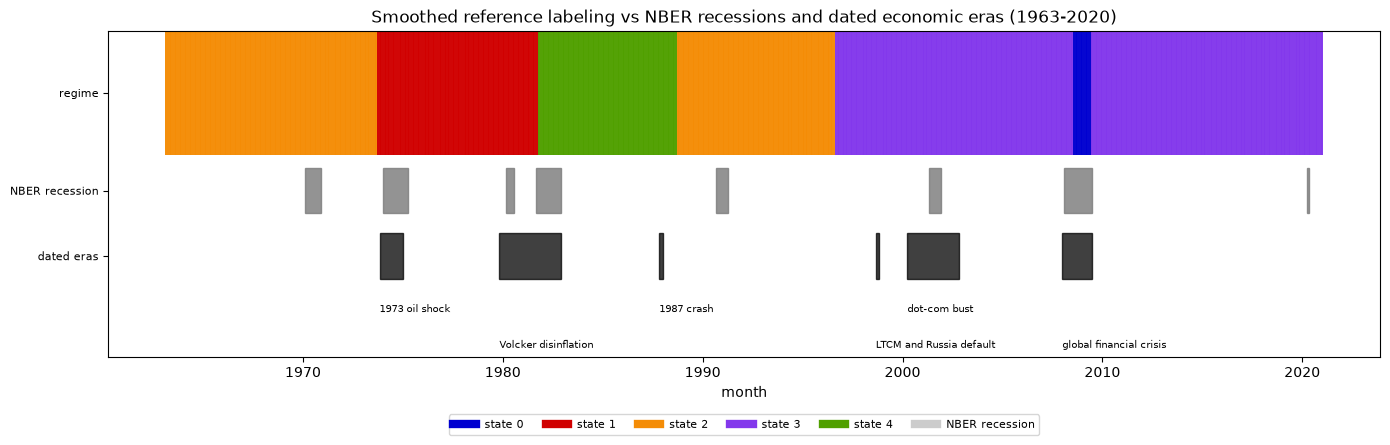

In [3]:
usrec = history.load_usrec_or_warn(cfg)

if usrec is None:
    print(
        "DEGRADED: the FRED USREC fetch failed. NBER recession shading is OMITTED "
        "from the timeline below. The dated ECONOMIC_EVENTS overlay still renders, "
        "so the chart is incomplete but not blank. Do NOT record a sign-off verdict "
        "against recession agreement while this warning is showing — check "
        "FRED_API_KEY and network reachability first (D-10, T-06-13)."
    )
    recessions = None
else:
    recessions = history.recession_periods(usrec)
    print(f"USREC loaded: {len(recessions)} NBER recession periods over the plotted span.")

fig_timeline = regime.plot_regime_timeline(
    reference_states,
    recessions=recessions,
    events=history.ECONOMIC_EVENTS,
    title="Smoothed reference labeling vs NBER recessions and dated economic eras (1963-2020)",
)


### What to check on that chart

Read the coloured bands against these six dated transitions in the reference
labeling. They are the transitions the labeling actually produces; the question is
whether each one lands where an economic historian would put a regime break.

| transition | into state | reading being checked |
|---|---|---|
| **1973-09** | 1 | oil shock / stagflation |
| **1981-10** | 4 | Volcker |
| **1988-09** | 2 | post-Volcker disinflation |
| **1996-08** | 3 | late-90s expansion |
| **2008-07** | 0 | GFC — state 0 is the 1.6%-occupancy crisis state |
| **2009-06** | 3 | recovery |

**Expect a genuine question here, not a foregone negative.** An earlier reading of
this project assumed the labeling was degenerate and that a negative verdict was
near-certain; that prior is now wrong (CONTEXT.md Amendment 2 item E). The
labeling above may well map onto recognizable history — judge it, do not assume
the answer in either direction. D-16 remains the safety valve: a negative verdict
is recorded and does not block.


occupancy shares (sum = 1.000000000000):
  state 0:  1.5827%
  state 1: 13.9568%
  state 2: 31.9424%
  state 3: 40.5755%
  state 4: 11.9424%
pooled median sojourn: 97.0 months
states below the 5% §4.4 soft floor (report-only, not blocking): [0]


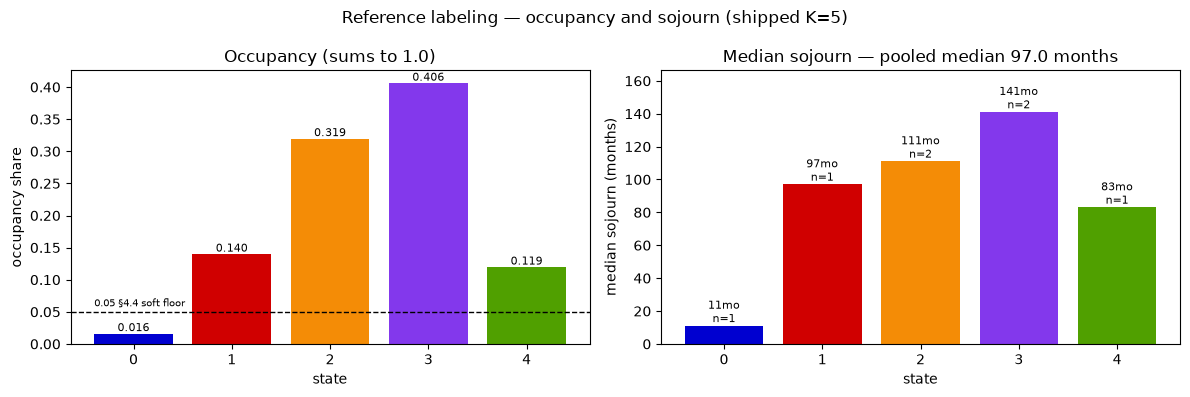

In [4]:
occ = occupancy_and_sojourns(reference_states.to_numpy(), n_states=5)

# Plausibility band before rendering: shares must each lie in [0, 1] and sum to
# 1.0, or this raises and the notebook stops rather than drawing a chart of an
# impossible occupancy (06-VALIDATION.md).
low_states = drift.assert_regime_occupancy_plausible(occ["occupancy_pct"])

print("occupancy shares (sum = %.12f):" % sum(occ["occupancy_pct"].values()))
for state_id, share in occ["occupancy_pct"].items():
    print(f"  state {state_id}: {share:8.4%}")
print("pooled median sojourn:", occ["overall_median_sojourn_months"], "months")
print(
    "states below the 5% §4.4 soft floor (report-only, not blocking):",
    low_states or "none",
)

fig_occ = regime.plot_occupancy_and_sojourn(
    reference_states, n_states=5, title="Reference labeling — occupancy and sojourn (shipped K=5)"
)


to,0,1,2,3,4
from,,,,,
0,0.9091,0.0000,0.000,0.0909,0.0000
1,0.0000,0.9897,0.000,0.0000,0.0103
2,0.0000,0.0045,0.991,0.0045,0.0000
3,0.0036,0.0000,0.000,0.9964,0.0000
4,0.0000,0.0000,0.012,0.0000,0.9880


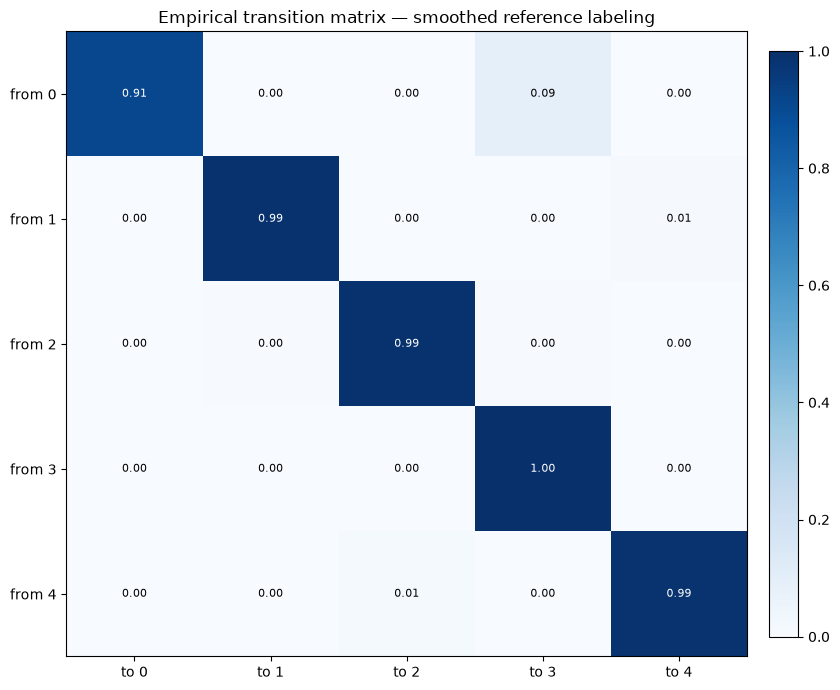

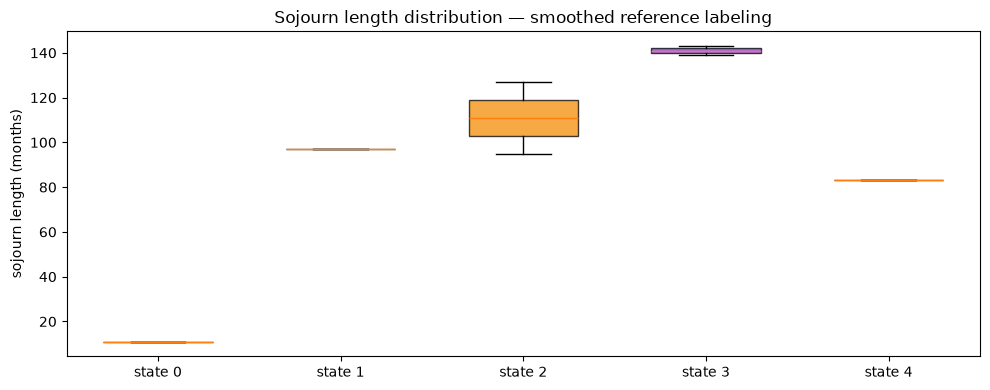

In [5]:
transitions = empirical_transition_matrix(reference_states)
display(transitions.round(4))

fig_trans = regime.plot_transition_matrix(
    transitions, title="Empirical transition matrix — smoothed reference labeling"
)
fig_sojourn = regime.plot_sojourn_distribution(
    reference_states, n_states=5, title="Sojourn length distribution — smoothed reference labeling"
)


## Regime × era contingency (D-13)

The timeline answers "do these regimes look real" visually. The two tables below
stop the eye from seeing a pattern that is not there, by giving both directions of
the same crosstab:

- **Contingency** — the share of each era's months falling in each state. Rows sum
  to 1.0.
- **Marginals** — the share of each state's months falling inside each era. Rows do
  not sum to 1.0, and the named eras overlap the NBER recession row by
  construction.

One direction alone misleads: a state can dominate a short era simply by being the
most common state overall, which only the marginal view exposes.

**Both are purely descriptive. No significance test is computed** — a p-value here
would invite treating "the regimes are real" as a passed test, and any number that
informs a choice belongs in the trial registry (D-13).


row sums (must be 1.0): {'1973 oil shock': 1.0, 'Volcker disinflation': 1.0, '1987 crash': 1.0, 'LTCM and Russia default': 1.0, 'dot-com bust': 1.0, 'global financial crisis': 1.0, 'NBER recession': 1.0, 'all months': 1.0}


,0,1,2,3,4
1973 oil shock,0.0000,1.0000,0.0000,0.0000,0.0000
Volcker disinflation,0.0000,0.6316,0.0000,0.0000,0.3684
1987 crash,0.0000,0.0000,0.0000,0.0000,1.0000
LTCM and Russia default,0.0000,0.0000,0.0000,1.0000,0.0000
dot-com bust,0.0000,0.0000,0.0000,1.0000,0.0000
global financial crisis,0.5789,0.0000,0.0000,0.4211,0.0000
NBER recession,0.1294,0.2824,0.2235,0.2000,0.1647
all months,0.0158,0.1396,0.3194,0.4058,0.1194


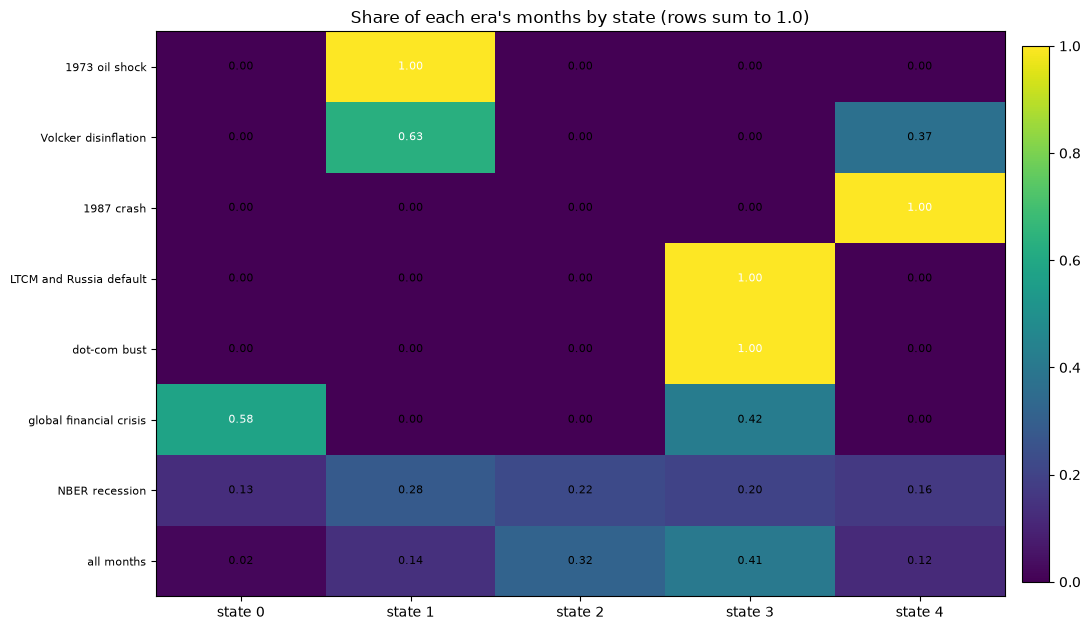

,0,1,2,3,4
1973 oil shock,0.0,0.1546,0.0000,0.0000,0.0000
Volcker disinflation,0.0,0.2474,0.0000,0.0000,0.1687
1987 crash,0.0,0.0000,0.0000,0.0000,0.0361
LTCM and Russia default,0.0,0.0000,0.0000,0.0106,0.0000
dot-com bust,0.0,0.0000,0.0000,0.1135,0.0000
global financial crisis,1.0,0.0000,0.0000,0.0284,0.0000
NBER recession,1.0,0.2474,0.0856,0.0603,0.1687
all months,1.0,1.0000,1.0000,1.0000,1.0000


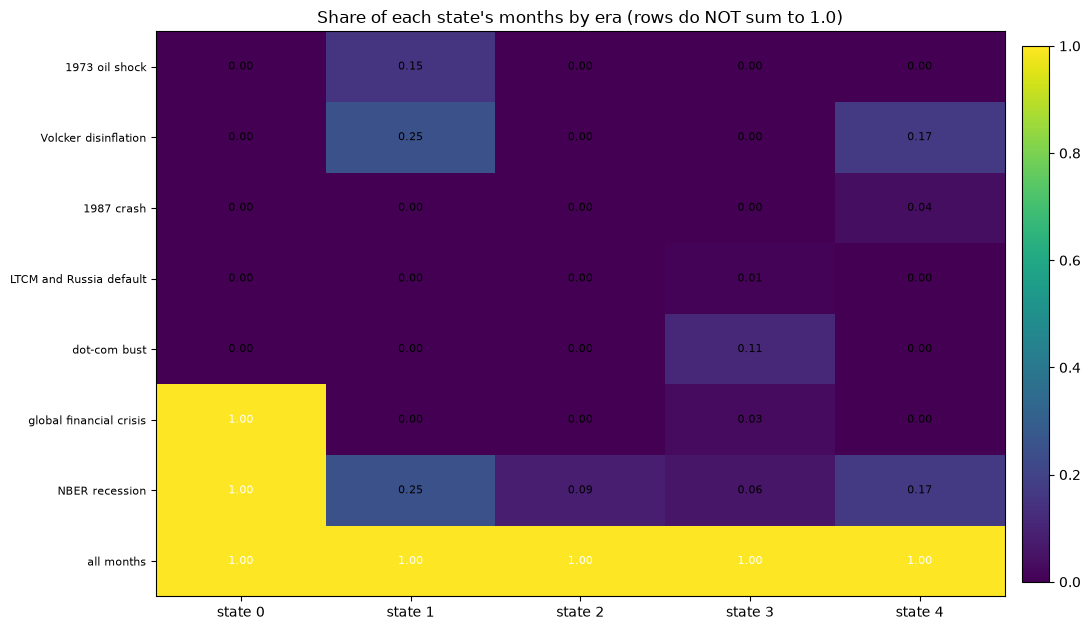

In [6]:
contingency = history.regime_era_contingency(reference_states, usrec=usrec, n_states=5)
print("row sums (must be 1.0):", contingency.sum(axis=1).round(12).to_dict())
display(contingency.round(4))
fig_cont = history.plot_era_contingency(
    contingency, title="Share of each era's months by state (rows sum to 1.0)"
)

marginals = history.regime_era_marginals(reference_states, usrec=usrec, n_states=5)
display(marginals.round(4))
fig_marg = history.plot_era_contingency(
    marginals, title="Share of each state's months by era (rows do NOT sum to 1.0)"
)


## The shipped labeler's own output — 1990 onward only

The soft confidences and per-state profiles below come from the **shipped**
`label_regimes()` output, not the reference. They cover **1990-01 to 2020-12
only**, because `fred_vix` begins in 1990 and the labeler drops rows with any
missing lean feature. That is 372 of the reference's 695 months.

This span mismatch is not a bug in either path — it is the same underlying fact
audit item A13 names: the evaluation's reference and the shipped labeler are fit
on different feature sets, so they cover different history and their state ids are
canonicalized independently.


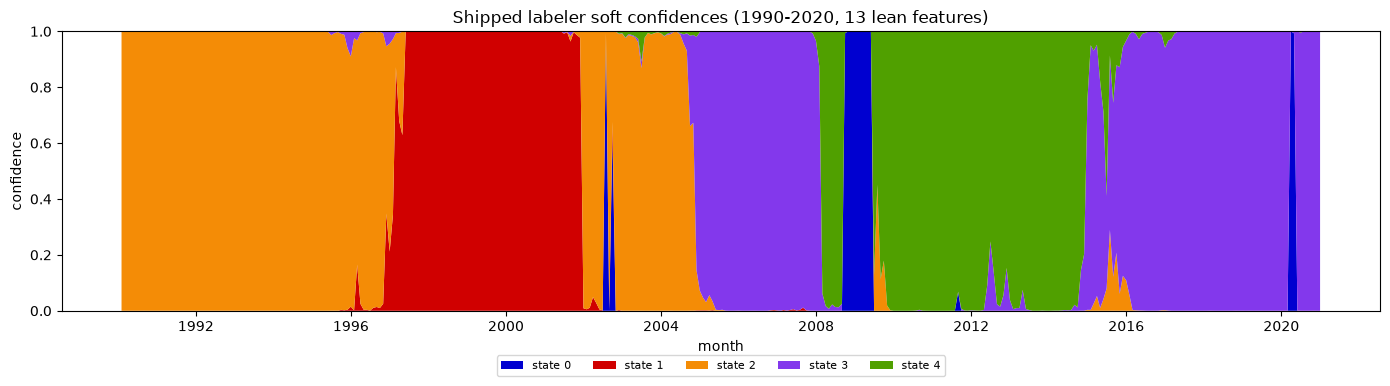

,state,profile
0,0,"state 0: high credit_spread_baa_aaa, high fred..."
1,1,"state 1: high cape_shiller, low div_yield, low..."
2,2,"state 2: low oil, low gold, high real_rate_level"
3,3,"state 3: low real_rate_level, low curve_10y3m,..."
4,4,"state 4: high oil, high gold, high curve_10y2y"


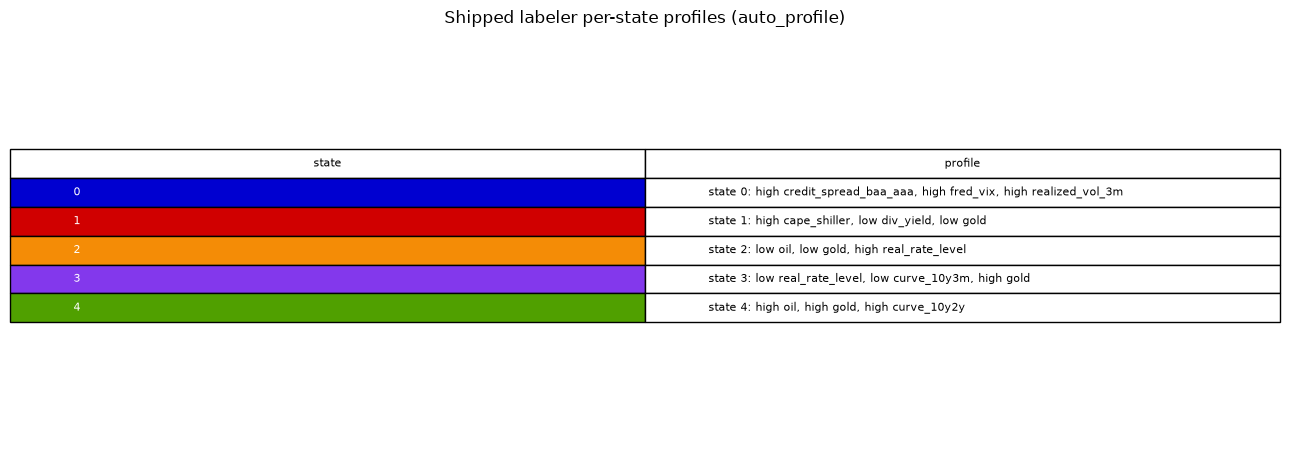

shipped labeler trailing-24-month label churn: nan


In [7]:
fig_conf = regime.plot_soft_confidences(
    labeling["regime_confidences"],
    title="Shipped labeler soft confidences (1990-2020, 13 lean features)",
)
display(labeling["regime_profiles"])
fig_profiles = regime.plot_regime_profiles(
    labeling["regime_profiles"], title="Shipped labeler per-state profiles (auto_profile)"
)

# §4.4 churn: label_regimes compares against the PREVIOUS regime_labels
# checkpoint in the same (scratch) namespace, so this is nan on a first run.
print("shipped labeler trailing-24-month label churn:", labeling["churn"])


## Audit item A13 — the three labelings side by side

This is the section CONTEXT.md Amendment 2 item F added to P3, and it is this
notebook's most valuable output.

**The finding, in its own terms.** The evaluation's §5.4 detection lag is defined
as how long the *filtered* path takes to agree with the *smoothed reference*. But
the reference is fit on a **fixed 9 columns** across all 695 months, while the
walk-forward's active feature set **changes seven times** across the backtest —
4 → 6 → 8 → 9 → 10 → 12 → 13 columns, each admitted once it clears
`feature_min_history` in-window. Two labelings computed from different and
time-varying inputs will disagree for reasons that have nothing to do with
detection delay, so **the reported lag is not a lag measurement**.

Three things below make that inspectable:

1. the active-feature-count timeline and its seven change dates, reconstructed
   from `backtest.driver._window_active_features` (the driver's own rule, imported
   rather than reimplemented — no walk-forward is run);
2. all three labelings drawn on a shared time axis with those change dates marked,
   with each track blank where its labeling has no value (the coverage gaps are
   the point, so nothing is silently reindexed);
3. the measured reference-versus-filtered disagreement.

**This section makes A13 inspectable. It does not resolve A13.**


walk-forward decision dates reconstructed: 588
feature-set changes: 7
  1972-01-31  n_active= 4  ['cape_shiller', 'credit_spread_baa_aaa', 'curve_10y3m', 'div_yield']
  1972-02-29  n_active= 6  ['cape_shiller', 'credit_spread_baa_aaa', 'curve_10y3m', 'div_yield', 'realized_vol_1m', 'trailing_return_1m']
  1972-04-30  n_active= 8  ['cape_shiller', 'credit_spread_baa_aaa', 'curve_10y3m', 'div_yield', 'realized_vol_1m', 'realized_vol_3m', 'trailing_return_1m', 'trailing_return_3m']
  1973-02-28  n_active= 9  ['cape_shiller', 'credit_spread_baa_aaa', 'curve_10y3m', 'div_yield', 'real_rate_level', 'realized_vol_1m', 'realized_vol_3m', 'trailing_return_1m', 'trailing_return_3m']
  1986-06-30  n_active=10  ['cape_shiller', 'credit_spread_baa_aaa', 'curve_10y2y', 'curve_10y3m', 'div_yield', 'real_rate_level', 'realized_vol_1m', 'realized_vol_3m', 'trailing_return_1m', 'trailing_return_3m']
  1995-02-28  n_active=12  ['cape_shiller', 'credit_spread_baa_aaa', 'curve_10y2y', 'curve_10y3m', 'div_y

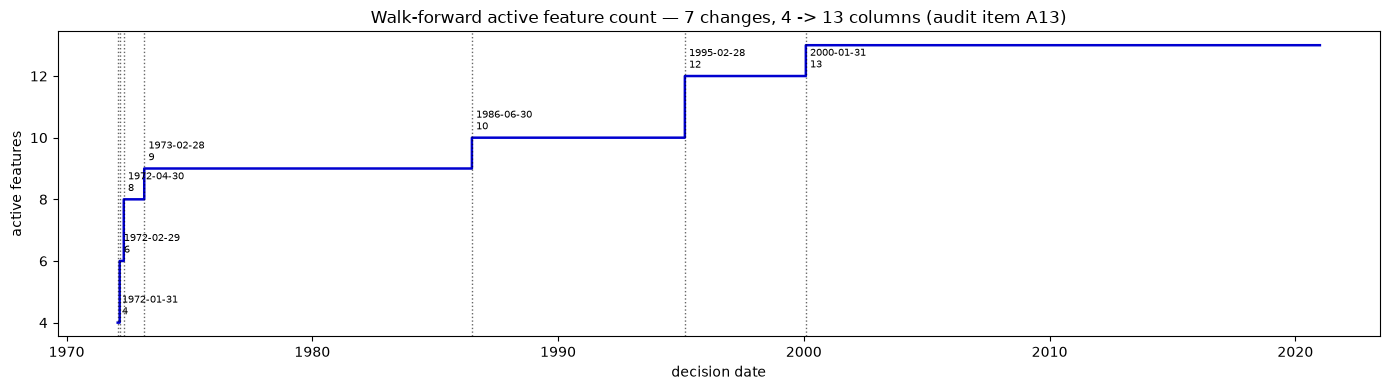

In [8]:
backtest_cfg = cfg["backtest"]
lean_cols = sorted(lean_feature_set(cfg) & set(monthly_features_dev.columns))

feature_timeline = regime.active_feature_count_timeline(
    monthly_features_dev,
    lean_cols,
    min_history=backtest_cfg["feature_min_history"],
    min_train=backtest_cfg["min_train_months"],
)
change_dates = regime.feature_set_change_dates(feature_timeline)

print(f"walk-forward decision dates reconstructed: {len(feature_timeline)}")
print(f"feature-set changes: {len(change_dates)}")
for stamp in change_dates:
    row = feature_timeline.loc[stamp]
    print(f"  {stamp.date()}  n_active={int(row['n_active']):2d}  {row['active']}")

fig_active = regime.plot_active_feature_count(
    feature_timeline,
    title="Walk-forward active feature count — 7 changes, 4 -> 13 columns (audit item A13)",
)


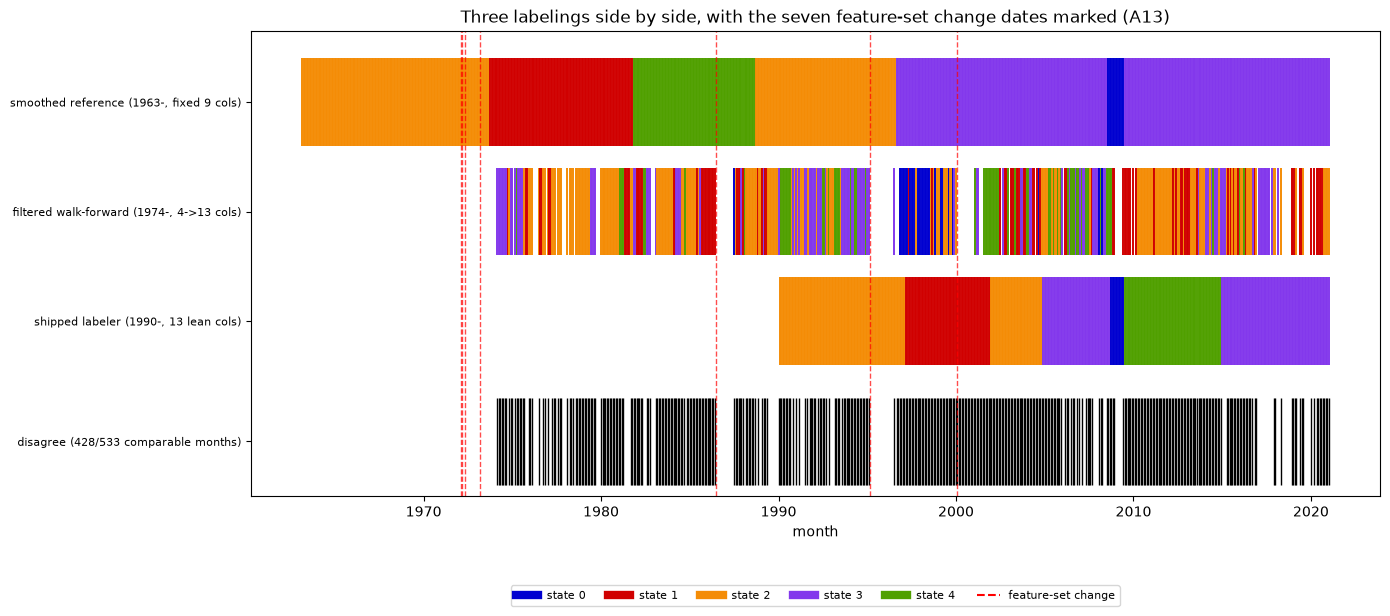

reference vs filtered disagreement:
  n_compared: 470
  n_disagree: 389
  pct_disagree: 0.8276595744680851
  first_common_date: 1974-02-28 00:00:00
  last_common_date: 2020-12-31 00:00:00

reference state (rows) x filtered state (columns) counts:


comparison,0,1,2,3,4
reference,,,,,
0,0,3,0,0,3
1,0,11,44,18,4
2,0,4,23,33,18
3,27,55,80,43,36
4,1,22,29,12,4


In [9]:
fig_compare = regime.plot_label_comparison(
    {
        "smoothed reference (1963-, fixed 9 cols)": reference_states,
        "filtered walk-forward (1974-, 4->13 cols)": filtered_states,
        "shipped labeler (1990-, 13 lean cols)": shipped_states,
    },
    change_dates=change_dates,
    title="Three labelings side by side, with the seven feature-set change dates marked (A13)",
)

disagreement = regime.label_disagreement(reference_states, filtered_states)
print("reference vs filtered disagreement:")
for key in ("n_compared", "n_disagree", "pct_disagree", "first_common_date", "last_common_date"):
    print(f"  {key}: {disagreement[key]}")
print()
print("reference state (rows) x filtered state (columns) counts:")
display(disagreement["per_state_confusion"])


### Reading the disagreement number honestly

`n_compared` is **470, not 588** — the filtered path exists only for the
non-degraded steps, and it starts in 1974-02. So the comparison above covers
about 80% of the walk-forward and none of its first two years, on top of the
feature-set mismatch. That is a *second*, independent reason the disagreement is
not purely detection delay.

A further caveat visible in the confusion table: the two labelings are
**canonicalized independently**, so their state ids need not denote the same
regimes. A high raw disagreement is therefore compatible with the two paths
finding similar regime *structure* under different id assignments — which is
exactly why a single scalar here cannot be read as a lag.

No plausibility band is claimed around this number. A plausible-looking figure
computed against a mismatched target is precisely what A13 is.


In [10]:
# Single-source caveat string (core.A13_CAVEAT) — rendered identically here and
# in P6, so the wording cannot drift between notebooks.
print(pplot.A13_CAVEAT)
print()
print(
    "Coverage addendum measured in plan 06-02: 118 of 588 walk-forward steps "
    "(20.1%) are degraded and excluded from per_step_metrics, so the filtered "
    "path has 470 rows and does not begin until 1974-02 — ~2 years after the "
    "backtest's 1972-01 start. The reference-vs-filtered comparison therefore "
    "covers ~80% of steps and is entirely absent early."
)


NOT INTERPRETABLE (audit item A13): this ratio compares a fixed-feature 'smoothed reference' labeling against the walk-forward's own per-window 'filtered' labeling, whose active feature set changes 7 times across the backtest (4 -> 6 -> 8 -> 9 -> 10 -> 12 -> 13 features). Their disagreement is therefore not purely detection delay, and no plausibility band around this number resolves that until A13 is settled.

Coverage addendum measured in plan 06-02: 118 of 588 walk-forward steps (20.1%) are degraded and excluded from per_step_metrics, so the filtered path has 470 rows and does not begin until 1974-02 — ~2 years after the backtest's 1972-01 start. The reference-vs-filtered comparison therefore covers ~80% of steps and is entirely absent early.


## Design §4.4 acceptance criteria — report-only (D-14)

These are reported, not gated. This notebook renders diagnostics for the **shipped
configuration only** — `K=5`, `lambda=52.0`, `n_restarts=10`. No cell above sweeps
`K`, `lambda`, or `n_restarts`, and none changes any hyperparameter. Tuning
arrives in a later phase and stays consistent with Phase 3 D-02.

Observed above, for the smoothed reference labeling:

- **Occupancy** — 1.58 / 13.96 / 31.94 / 40.58 / 11.94 percent, summing to 1.0.
  State 0 sits below the 5% §4.4 soft floor; it is the crisis state and the
  labeler logs this at WARNING without blocking, by design.
- **Sojourn** — pooled median 97.0 months across all runs of all states.
- **Churn** — the trailing-24-month label churn is printed by the shipped-labeler
  cell above. `label_regimes()` computes it against the *previous* `regime_labels`
  checkpoint in the same namespace, so on a first run in a fresh scratch namespace
  it is `nan` — the documented first-run behavior, not a failure.
- **Detection lag / sojourn ratio** — reported by the evaluation, **not
  interpretable pending A13** (see the caveat cell above). No band is asserted
  around it here or anywhere else.


## Cold-Start Sign-Off

Record the cold-start judgement here, then save the notebook. This is a plain
markdown cell by design — there is no `sign_off()` helper and no machine-readable
ledger (D-15).

**Date:** 2026-09-10

**Verdict:** accept-with-caveats

**Reasoning:** (recorded by Glenn Strycker, operator)

The regimes are accepted as **predictable and interpretable** — the crisis-era mapping
is clean and legible (1973 oil shock → state 1 at 100%; 1987 crash → state 4 at 100%;
LTCM and dot-com → state 3 at 100%; GFC → state 0 at 58% against a 1.58% baseline).
That structure is real and worth keeping.

The caveat is one of **objective, not quality**. This labeling is optimised for the
*negative* — drawdowns and crises. The NBER-recession row spreading near the
unconditional baseline (0.13 / 0.28 / 0.22 / 0.20 / 0.16) confirms it: these are crisis
states, not business-cycle states. State 0 is, column-normalised, 100% GFC months — a
GFC detector rather than a general crisis detector.

Avoiding drawdowns matters, but the decision this platform actually has to serve is
**"would proposed portfolio A outperform portfolio B right now?"** — a relative-
performance question across stocks / bonds / commodities / precious metals / cash.
The current regimes are not primarily informative for that question during ordinary
market conditions, which is where most months live.

**Direction set at sign-off (does not block this phase):** rather than raising K within
the same feature space — which would subdivide the existing stress axis and worsen the
already-thin state 0 — pursue a **second, independent regime classifier** fitted on
leadership / relative-strength features (tech growth, small-cap growth, inflation,
stagflation, strong-bond regimes, and similar). The existing crisis classifier is kept
as-is. The two labelings are then carried jointly as features into the downstream
differential-equation models and portfolio optimisers, where their interaction is
expected to supply lift that neither provides alone.

Recorded per **D-16**: a verdict is recorded and does not block. Accepted with the
caveat above; the follow-on work is tracked separately, not as a Phase 6 defect.

---

Per **D-16**: a negative verdict is recorded and **does not block** the phase. A
finding that the five regimes do not map onto economic history would be an *input* to
Phases 7 and 8, not a failure of this phase.
